# Extraction automatique de palette de couleurs par Mean Shift

En design/branding/e-commerce, on veut extraire **les couleurs dominantes** d’une photo produit ou d’un visuel marketing :
- Définir une **palette** cohérente (couleurs principales/secondaires).
- Créer des **variantes de visuels** (posterization, style “cartoon”) ou chaque pixel devient la couleur dominante la plus proche.

## Pourquoi Mean Shift ?
- **Non paramétrique** : pas besoin de fixer un nombre de couleurs $k$.
- Cherche les **modes de densité** directement dans l’espace **RGB**.
- Donne une **palette naturelle** (centres de modes), adaptée à l’image.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from skimage import io, util, color
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import pairwise_distances_argmin

IMG_DIR = Path("images")
img_path = IMG_DIR / "image1.png" 

# Chargement de l'image (RGB) + échantillonnage de pixels

On convertit en **float [0,1]**, on gère automatiquement **NB** / **RGBA** en **RGB**.
On **échantillonne** pour estimer la densité plus vite (ex. 20k pixels).

Image: (379, 504) | pixels: 191016 | échantillon: 20000


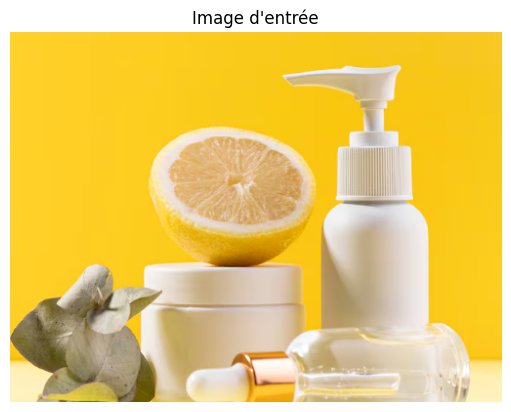

In [2]:
# Chargement robuste en RGB float32
img = io.imread(img_path)
img = util.img_as_float32(img)

if img.ndim == 2:  # grayscale -> RGB
    img = np.stack([img, img, img], axis=-1)
elif img.ndim == 3 and img.shape[-1] == 4:  # RGBA -> RGB (alpha composité sur fond blanc)
    img = color.rgba2rgb(img).astype(np.float32)

H, W, _ = img.shape
pixels = img.reshape(-1, 3)  # (N,3) en RGB

# Échantillonnage pour accélérer le clustering
rng = np.random.default_rng(42)
n_sub = min(20000, pixels.shape[0])
idx = rng.choice(pixels.shape[0], size=n_sub, replace=False)
X_sub = pixels[idx]

print("Image:", (H, W), "| pixels:", pixels.shape[0], "| échantillon:", X_sub.shape[0])

plt.imshow(img)
plt.axis("off")
plt.title("Image d'entrée")
plt.show()